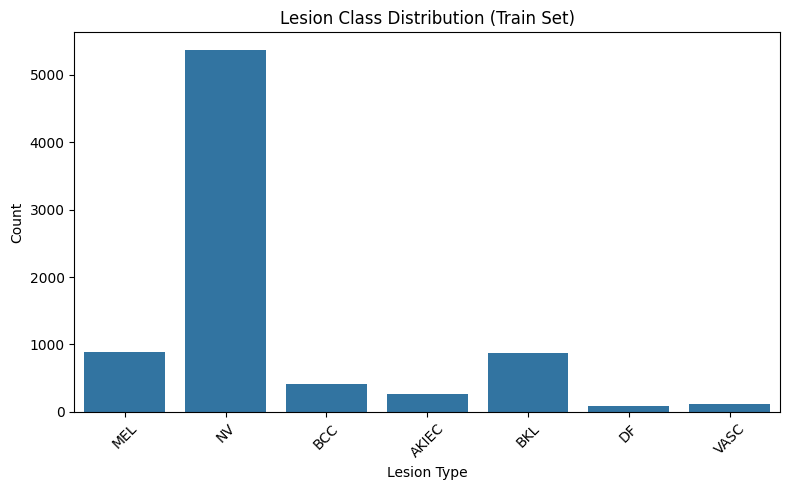

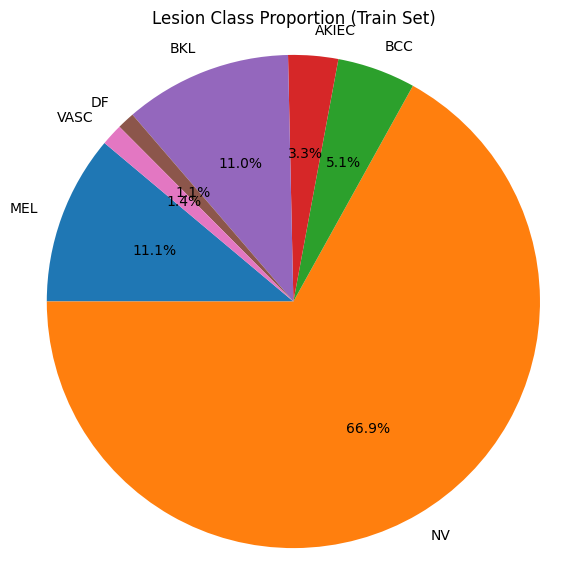

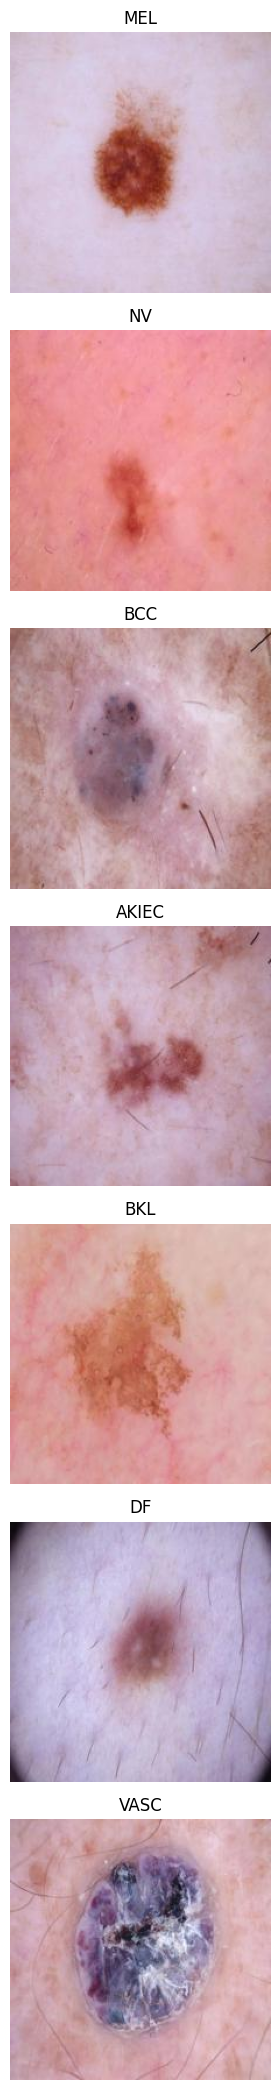

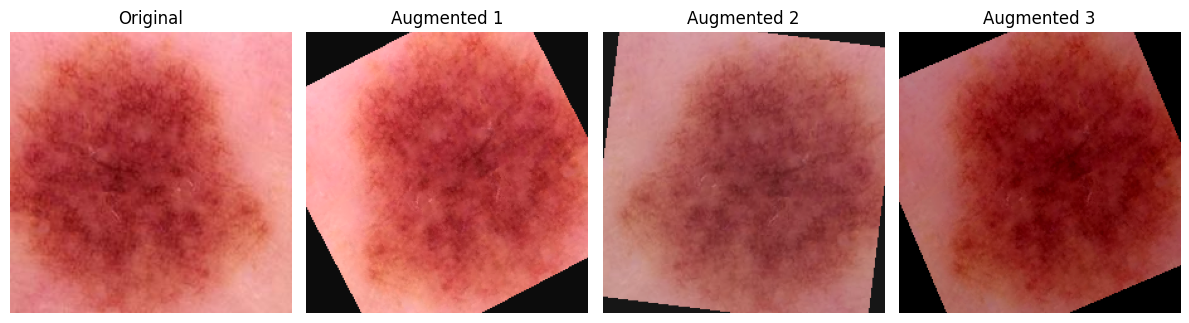

Sample shape: torch.Size([3, 224, 224]), Label index: 1, Class: NV


In [25]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns

# Device setup (optional here since no training, but good practice)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class columns and mappings
class_columns = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
idx_to_class = {i: c for i, c in enumerate(class_columns)}
class_to_idx = {c: i for i, c in enumerate(class_columns)}

# Load CSV metadata
train_df = pd.read_csv("train_df_processed.csv")
val_df = pd.read_csv("val_df_processed.csv")

# === EDA ===

# Plot class distribution in training data
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='label_idx', order=sorted(train_df['label_idx'].unique()))
plt.title("Lesion Class Distribution (Train Set)")
plt.xticks(ticks=range(len(class_columns)), labels=[idx_to_class[i] for i in range(len(class_columns))], rotation=45)
plt.xlabel("Lesion Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Pie chart of class proportions
class_counts = train_df['label_idx'].value_counts().sort_index()
plt.figure(figsize=(7, 7))
plt.pie(class_counts, labels=[idx_to_class[i] for i in class_counts.index], autopct='%1.1f%%', startangle=140)
plt.title("Lesion Class Proportion (Train Set)")
plt.axis("equal")
plt.show()

# Show one example image per class
def show_class_samples(df, image_column='image_path', label_column='label_idx', n=1):
    plt.figure(figsize=(15, 3 * len(class_columns)))
    
    for idx in range(len(class_columns)):
        sample = df[df[label_column] == idx].sample(n)
        for i, row in enumerate(sample.itertuples()):
            img = Image.open(getattr(row, image_column))
            plt.subplot(len(class_columns), n, idx * n + i + 1)
            plt.imshow(img)
            plt.title(f"{idx_to_class[idx]}")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

show_class_samples(train_df)

# Example data augmentation visualization
from torchvision import transforms
sample_row = train_df.sample(1).iloc[0]
img = Image.open(sample_row['image_path'])

augment = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4)
])

plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

for i in range(3):
    augmented_img = augment(img)
    plt.subplot(1, 4, i + 2)
    plt.imshow(augmented_img)
    plt.title(f"Augmented {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# === Dataset and DataLoader ===

class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.iloc[idx]['image_path']
        label = self.df.iloc[idx]['label_idx']
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# Define transforms WITHOUT augmentation (augmentation is usually done only during training)
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

train_dataset = SkinLesionDataset(train_df, transform=image_transforms)
val_dataset = SkinLesionDataset(val_df, transform=image_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Sanity check: print one sample's shape and label class
img, label = train_dataset[0]
print(f"Sample shape: {img.shape}, Label index: {label}, Class: {idx_to_class[label]}")


In [6]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import random



In [7]:
device = torch.device("cpu")


In [8]:
# Define class columns and mappings
class_columns = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
idx_to_class = {i: c for i, c in enumerate(class_columns)}
class_to_idx = {c: i for i, c in enumerate(class_columns)}


In [9]:
# Load training labels
train_df = pd.read_csv("train_df_processed.csv")

# # Add label_idx if not present
# if 'label_idx' not in train_df.columns:
#     train_df['label_idx'] = train_df[class_columns].values.argmax(axis=1)

# # Add image path
# train_df['image_path'] = train_df['image'].apply(lambda x: f"resizedTrainingData/{x}.jpg")

# # Check if images exist
# missing_train = train_df[~train_df['image_path'].apply(os.path.exists)]
# print(f"Missing train images: {len(missing_train)}")


In [10]:
# Load validation labels
val_df = pd.read_csv("val_df_processed.csv")

# # Fix column names if needed
# if 'image' not in val_df.columns:
#     val_df.reset_index(inplace=True)
#     val_df.rename(columns={'index': 'image'}, inplace=True)

# # Add label_idx
# val_df['label_idx'] = val_df[class_columns].values.argmax(axis=1)

# # Add image path
# val_df['image_path'] = val_df['image'].apply(lambda x: f"resizedValidationData/{x}.jpg")

# # Check for missing images
# missing_val = val_df[~val_df['image_path'].apply(os.path.exists)]
# print(f"Missing val images: {len(missing_val)}")


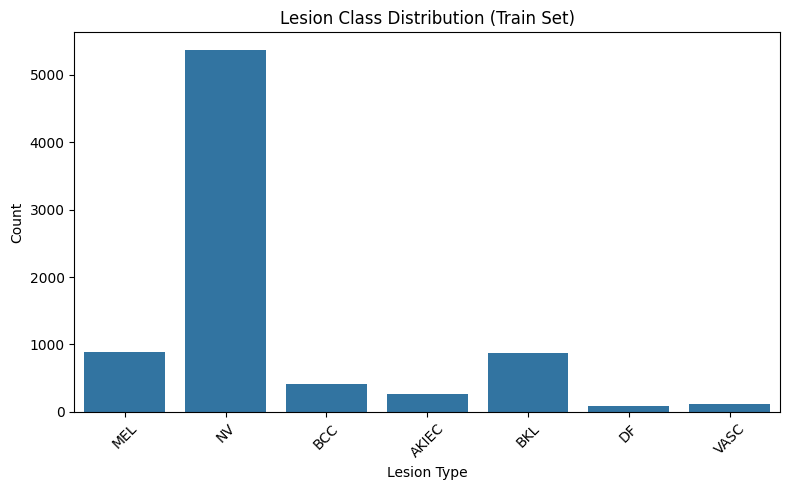

In [11]:
# Plot distribution in training data
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='label_idx', order=sorted(train_df['label_idx'].unique()))
plt.title("Lesion Class Distribution (Train Set)")
plt.xticks(ticks=range(len(class_columns)), labels=[idx_to_class[i] for i in range(len(class_columns))], rotation=45)
plt.xlabel("Lesion Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


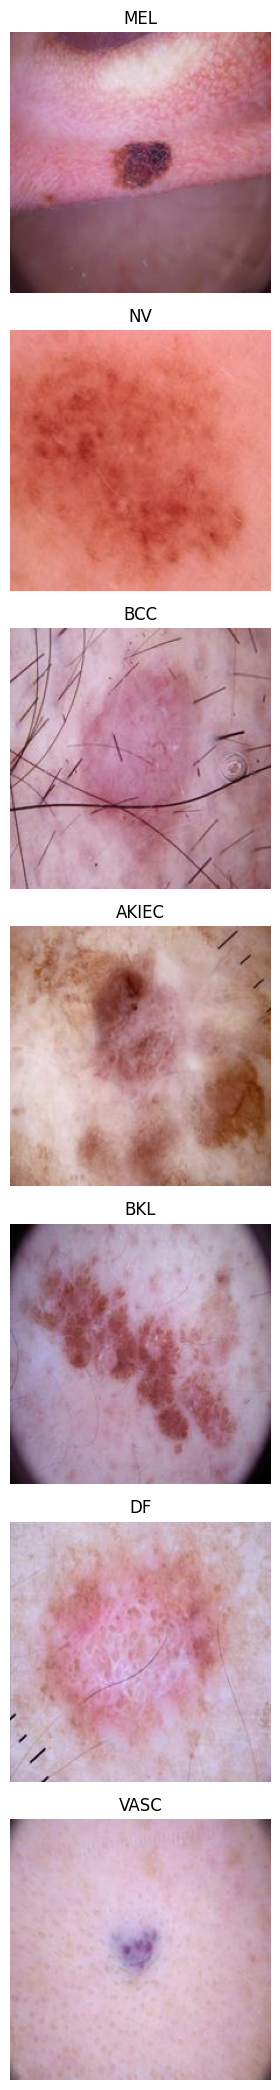

In [12]:
def show_class_samples(df, image_column='image_path', label_column='label_idx', n=1):
    plt.figure(figsize=(15, 3 * len(class_columns)))
    
    for idx in range(len(class_columns)):
        sample = df[df[label_column] == idx].sample(n)
        for i, row in sample.iterrows():
            img = Image.open(row[image_column])
            plt.subplot(len(class_columns), n, idx * n + 1)
            plt.imshow(img)
            plt.title(f"{idx_to_class[idx]}")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

show_class_samples(train_df)


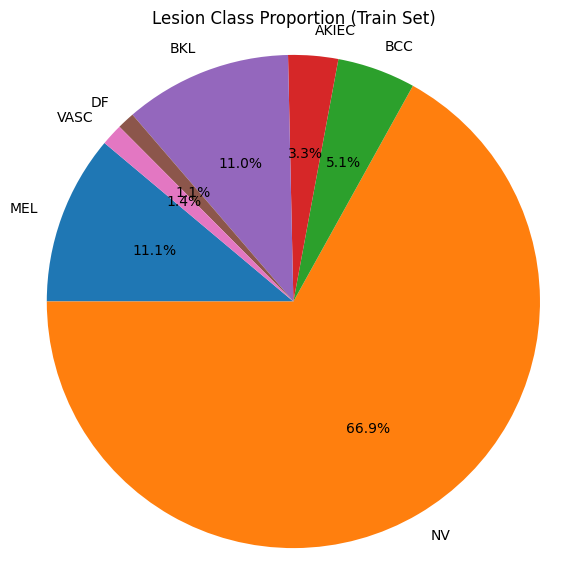

In [13]:
class_counts = train_df['label_idx'].value_counts().sort_index()
plt.figure(figsize=(7, 7))
plt.pie(class_counts, labels=[idx_to_class[i] for i in class_counts.index], autopct='%1.1f%%', startangle=140)
plt.title("Lesion Class Proportion (Train Set)")
plt.axis("equal")
plt.show()


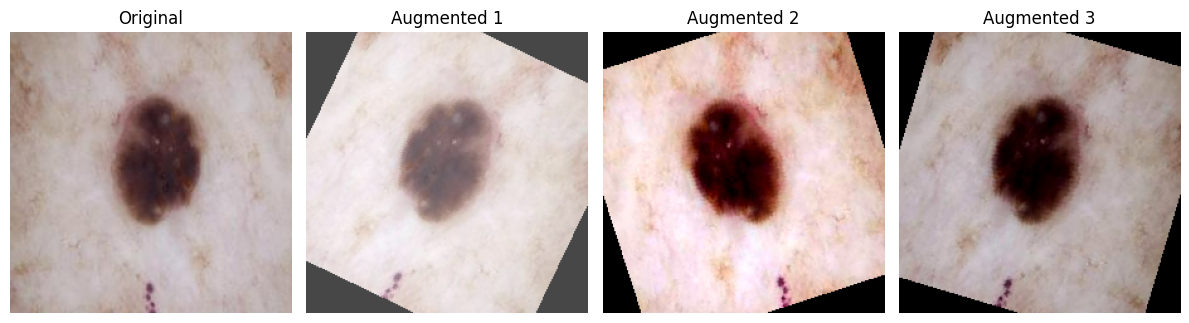

In [14]:
# Pick one random sample
sample_row = train_df.sample(1).iloc[0]
img = Image.open(sample_row['image_path'])

# Define transforms
augment = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4)
])

# Plot original and 3 augmented versions
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

for i in range(3):
    augmented_img = augment(img)
    plt.subplot(1, 4, i + 2)
    plt.imshow(augmented_img)
    plt.title(f"Augmented {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [15]:
class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.iloc[idx]['image_path']
        label = self.df.iloc[idx]['label_idx']
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


In [16]:
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Create datasets
train_dataset = SkinLesionDataset(train_df, transform=image_transforms)
val_dataset = SkinLesionDataset(val_df, transform=image_transforms)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


In [17]:
# Sanity check: Show sample image and label
img, label = train_dataset[0]
print(f"Sample shape: {img.shape}, Label index: {label}, Class: {idx_to_class[label]}")


Sample shape: torch.Size([3, 224, 224]), Label index: 1, Class: NV


In [18]:
# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_columns))

model = model.to(device)


/Users/anushekhan/skinLesionIdentifierProject/venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/anushekhan/skinLesionIdentifierProject/venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)


In [20]:
def train_model(model, criterion, optimizer, train_loader, val_loader, epochs=3):
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        accuracy = correct / total
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}, Accuracy: {accuracy:.4f}")


In [21]:
def evaluate_model(model, val_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return y_true, y_pred


In [22]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


In [23]:
# train_model(model, criterion, optimizer, train_loader, val_loader, epochs=3)

# y_true, y_pred = evaluate_model(model, val_loader)
# plot_confusion_matrix(y_true, y_pred, class_columns)
# print(classification_report(y_true, y_pred, target_names=class_columns))
